# GPU ORA: full models (ARCHS4 vs GTEx vs Recount2), shared gene universe

**Environment:** `clamp-analyses`

Dot plots in the style of `fig4.ipynb`'s panel A2 ("Full models"): one point per
dataset, comparing the best full-sample ARCHS4 model (rs_pct=100, K=1728, best of 3
seeds) against the full-sample GTEx and Recount2 models. Uses the shared-gene-universe
caches from `10_bp_msigdb_gpu_ora_shared_universe_analysis.ipynb` (5949 genes shared
across all three datasets, so `n_total_pathways` is identical within each library and
coverage % is directly comparable across datasets), filtered at FDR < 0.01.

Four panels: {GO:BP, MSigDB} x {CLAMPfull, CLAMPbase}.

In [6]:
library(here)
library(ggplot2)
library(dplyr)
library(scales)
library(patchwork)

input_dir <- here("output/03_model_biology/00_archs4/08_saturation_study/gpu_ora_shared_universe")
FDR_THRESHOLD <- 0.01

DATASET_COLORS <- c(ARCHS4 = "#0072B2", recount2 = "#56B4E9", GTEx = "#009E73")

theme_pub <- function(base_size = 7, base_line_size = 0.35) {
  theme_classic(base_size = base_size, base_family = "Helvetica") %+replace%
    theme(
      plot.title        = element_text(size = 8, face = "plain", hjust = 0.5, margin = margin(b = 2)),
      axis.line         = element_line(linewidth = base_line_size),
      axis.ticks        = element_line(linewidth = base_line_size),
      axis.text         = element_text(size = 7),
      axis.title        = element_text(size = 8, face = "plain"),
      legend.position   = "none",
      panel.grid        = element_blank(),
      plot.margin       = unit(c(2, 2, 2, 2), "mm")
    )
}

## Compute coverage per (library, dataset, model_type)

In [7]:
coverage_from_cache <- function(cache_path, meta_path, fdr = FDR_THRESHOLD) {
  meta  <- read.csv(meta_path, check.names = FALSE)
  terms <- read.csv(cache_path, check.names = FALSE)
  n_sig <- sum(terms$padj_min_across_lvs < fdr)
  data.frame(
    n_samples        = meta$n_samples[1],
    n_input_pathways = meta$n_total_msigdb[1],
    n_lvs            = meta$n_lvs[1],
    n_sig_pathways   = n_sig,
    prop_pathway     = n_sig / meta$n_total_msigdb[1]
  )
}

load_model_cov <- function(lib_name, model_type) {
  lib_dir <- file.path(input_dir, lib_name)

  # ARCHS4: best of the 3 seeds at the full-coverage anchor (rs_pct=100, K=1728)
  archs4_seeds <- lapply(1:3, function(seed) {
    tag <- sprintf("ARCHS4_%s_seed%d", model_type, seed)
    cbind(seed = seed, coverage_from_cache(
      file.path(lib_dir, paste0(tag, "_gpu_ora.csv")),
      file.path(lib_dir, paste0(tag, "_meta.csv"))
    ))
  })
  archs4_df <- do.call(rbind, archs4_seeds) %>%
    dplyr::arrange(dplyr::desc(n_sig_pathways), dplyr::desc(prop_pathway)) %>%
    dplyr::slice_head(n = 1) %>%
    dplyr::transmute(dataset = "ARCHS4", n_samples, n_input_pathways, n_lvs, n_sig_pathways, prop_pathway)

  gtex_df <- coverage_from_cache(
    file.path(lib_dir, sprintf("GTEx_%s_gpu_ora.csv", model_type)),
    file.path(lib_dir, sprintf("GTEx_%s_meta.csv", model_type))
  ) %>% dplyr::mutate(dataset = "GTEx") %>% dplyr::relocate(dataset)

  recount2_df <- coverage_from_cache(
    file.path(lib_dir, sprintf("Recount2_%s_gpu_ora.csv", model_type)),
    file.path(lib_dir, sprintf("Recount2_%s_meta.csv", model_type))
  ) %>% dplyr::mutate(dataset = "recount2") %>% dplyr::relocate(dataset)

  dplyr::bind_rows(gtex_df, recount2_df, archs4_df) %>%
    dplyr::mutate(dataset = factor(dataset, levels = c("GTEx", "recount2", "ARCHS4")))
}

cov_bp_full      <- load_model_cov("bp", "CLAMPfull")
cov_bp_base      <- load_model_cov("bp", "CLAMPbase")
cov_msigdb_full  <- load_model_cov("msigdb", "CLAMPfull")
cov_msigdb_base  <- load_model_cov("msigdb", "CLAMPbase")

print(cov_bp_full)
print(cov_bp_base)
print(cov_msigdb_full)
print(cov_msigdb_base)

   dataset n_samples n_input_pathways n_lvs n_sig_pathways prop_pathway
1     GTEx     17382             6151   578           4176    0.6789140
2 recount2     37032             4789   724           3961    0.8271038
3   ARCHS4    605614             6267  1728           5686    0.9072922
   dataset n_samples n_input_pathways n_lvs n_sig_pathways prop_pathway
1     GTEx     17382             6151   578           3607    0.5864087
2 recount2     37032             4789   724           1813    0.3785759
3   ARCHS4    605614             6267  1728           4566    0.7285783
   dataset n_samples n_input_pathways n_lvs n_sig_pathways prop_pathway
1     GTEx     17382            27948   578          17256    0.6174324
2 recount2     37032            24161   724          14683    0.6077149
3   ARCHS4    605614            28320  1728          23991    0.8471398
   dataset n_samples n_input_pathways n_lvs n_sig_pathways prop_pathway
1     GTEx     17382            27948   578          15128    0.

## Plot helper

In [8]:
make_full_models_plot <- function(model_cov, title, y_label) {
  y_max <- max(model_cov$n_sig_pathways) * 1.30
  path_yaxis <- scale_y_continuous(
    limits = c(0, y_max),
    breaks = scales::breaks_pretty(n = 6),
    expand = expansion(mult = c(0, 0.01))
  )

  model_cov_lab <- model_cov %>%
    dplyr::mutate(
      label_y = n_sig_pathways + y_max * 0.045,
      label   = paste0(n_sig_pathways, "\n", sprintf("%.0f%%", prop_pathway * 100))
    )

  x_labels <- setNames(
    paste0(as.character(model_cov_lab$dataset), "\n", scales::comma(model_cov_lab$n_samples)),
    as.character(model_cov_lab$dataset)
  )

  ggplot(model_cov_lab, aes(x = dataset, y = n_sig_pathways, fill = dataset)) +
    geom_point(shape = 23, size = 4.0, colour = "black", stroke = 0.9) +
    geom_text(aes(y = label_y, label = label),
              size = 2.6, fontface = "bold", lineheight = 0.9, vjust = 0, colour = "black") +
    scale_x_discrete(labels = x_labels, expand = expansion(add = 0.42)) +
    scale_fill_manual(values = DATASET_COLORS, guide = "none") +
    path_yaxis + coord_cartesian(clip = "off") +
    labs(x = NULL, y = y_label, title = title) +
    theme_pub() +
    theme(
      axis.text.x = element_text(size = 7),
      panel.grid.major.y = element_line(color = "grey90", linewidth = 0.28)
    )
}

options(repr.plot.width = 9, repr.plot.height = 5)

## GO:BP -- CLAMPfull vs CLAMPbase (FDR < 0.01)

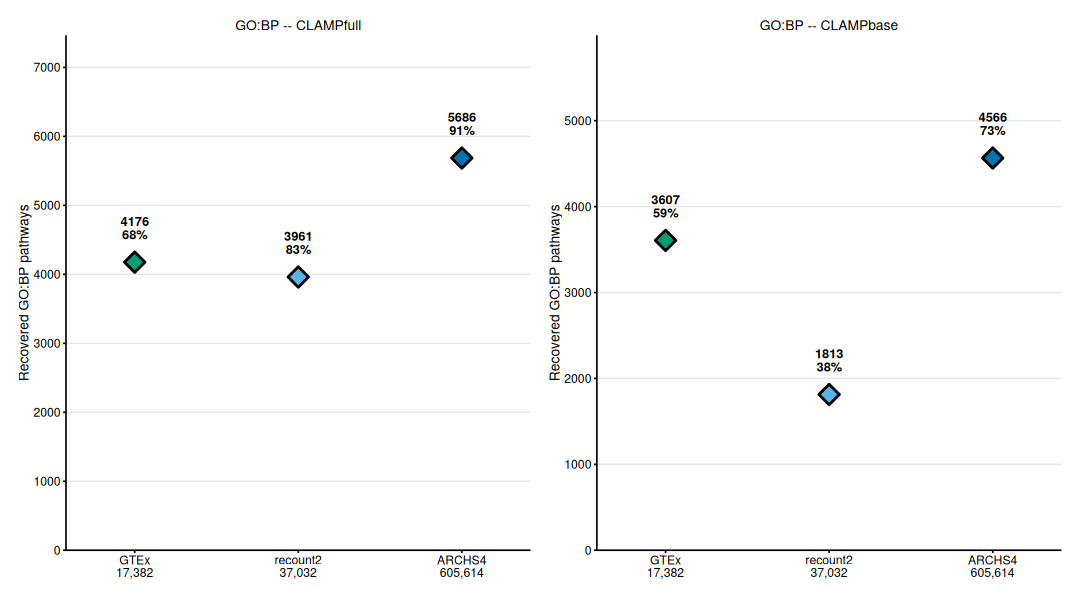

In [9]:
p_bp_full <- make_full_models_plot(cov_bp_full, "GO:BP -- CLAMPfull", "Recovered GO:BP pathways")
p_bp_base <- make_full_models_plot(cov_bp_base, "GO:BP -- CLAMPbase", "Recovered GO:BP pathways")
p_bp_full + p_bp_base

## MSigDB -- CLAMPfull vs CLAMPbase (FDR < 0.01)

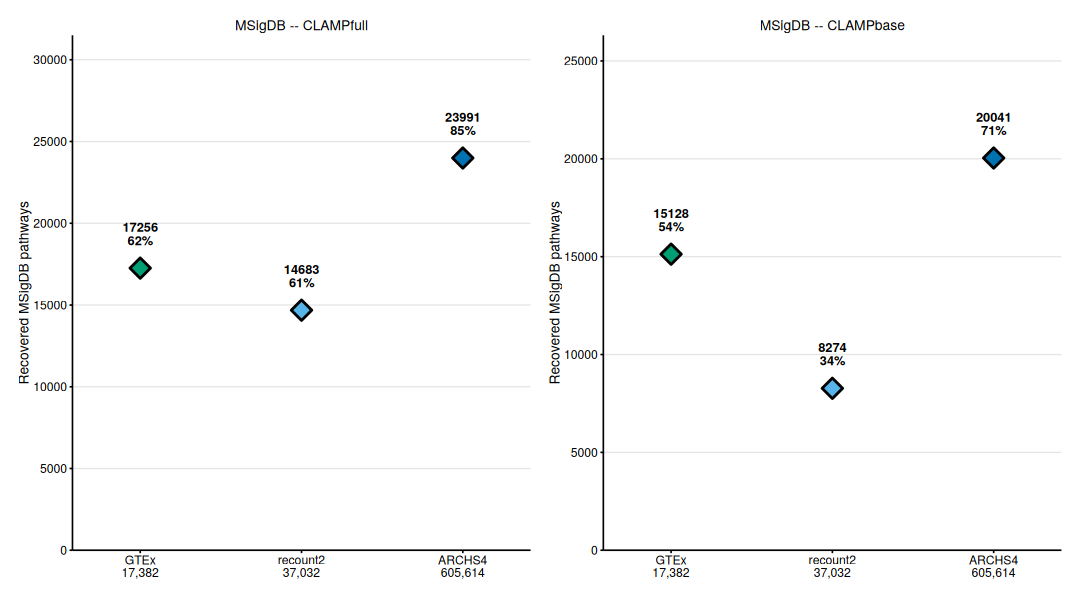

In [10]:
p_msigdb_full <- make_full_models_plot(cov_msigdb_full, "MSigDB -- CLAMPfull", "Recovered MSigDB pathways")
p_msigdb_base <- make_full_models_plot(cov_msigdb_base, "MSigDB -- CLAMPbase", "Recovered MSigDB pathways")
p_msigdb_full + p_msigdb_base